# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset yang digunakan adalah **Iris Dataset** dari scikit-learn.

Dataset ini berisi 150 sampel dari 3 spesies bunga iris (*Iris setosa*, *Iris versicolor*, *Iris virginica*) dengan 4 fitur numerik:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)

**Tujuan:** Klasifikasi spesies bunga berdasarkan ukuran kelopak dan mahkota bunga.

**Sumber:** Built-in dari `sklearn.datasets` (UCI ML Repository)

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print('Libraries imported successfully!')

Libraries imported successfully!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Load dataset
iris = load_iris()

# Buat DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Simpan raw data
os.makedirs('iris_raw', exist_ok=True)
df.to_csv('iris_raw/iris.csv', index=False)

print('Dataset berhasil dimuat!')
print(f'Shape: {df.shape}')
print(f'\nBeberapa baris pertama:')
df.head()

Dataset berhasil dimuat!
Shape: (150, 6)

Beberapa baris pertama:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# --- 4.1 Informasi Dasar Dataset ---
print('=== INFO DATASET ===')
print(df.info())
print('\n=== STATISTIK DESKRIPTIF ===')
df.describe()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

=== STATISTIK DESKRIPTIF ===


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# --- 4.2 Cek Missing Values dan Duplikat ---
print('=== MISSING VALUES ===')
print(df.isnull().sum())

print('\n=== DUPLIKAT ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

print('\n=== DISTRIBUSI KELAS ===')
print(df['species'].value_counts())

=== MISSING VALUES ===
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

=== DUPLIKAT ===
Jumlah baris duplikat: 1

=== DISTRIBUSI KELAS ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


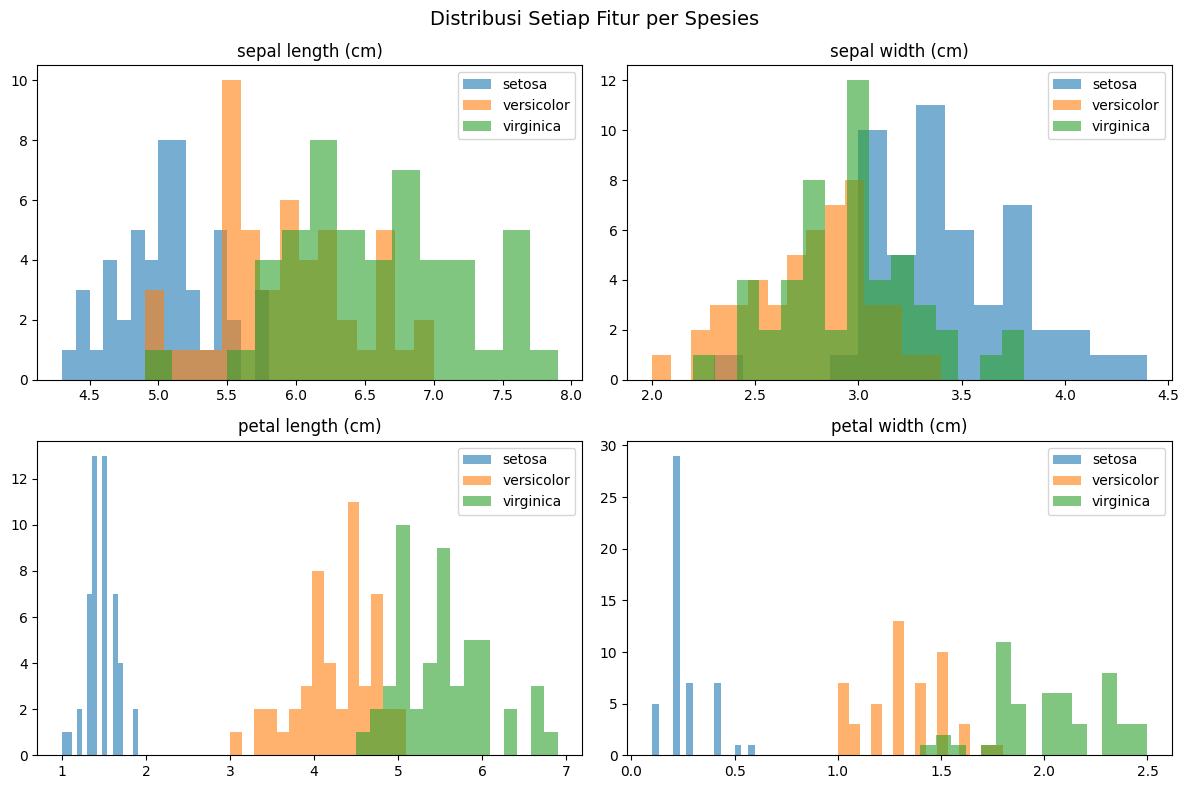

In [5]:
# --- 4.3 Visualisasi Distribusi Fitur ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = iris.feature_names

for idx, (ax, feature) in enumerate(zip(axes.flatten(), features)):
    for species in df['species'].unique():
        subset = df[df['species'] == species][feature]
        ax.hist(subset, alpha=0.6, label=species, bins=15)
    ax.set_title(feature)
    ax.legend()

plt.suptitle('Distribusi Setiap Fitur per Spesies', fontsize=14)
plt.tight_layout()
plt.show()

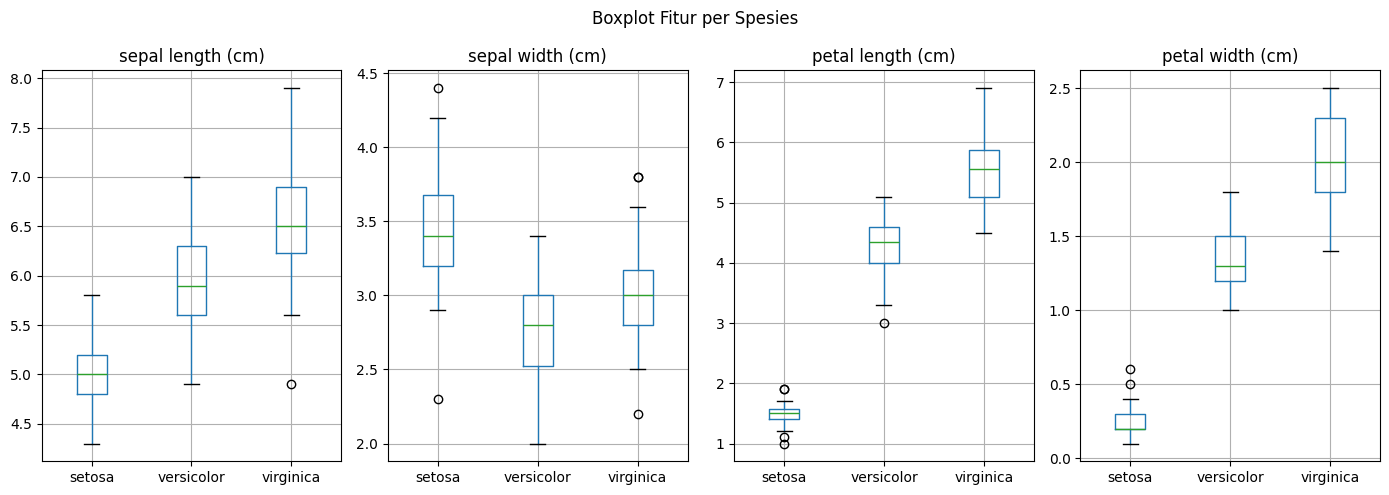

In [6]:
# --- 4.4 Boxplot untuk deteksi outlier ---
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for ax, feature in zip(axes, features):
    df.boxplot(column=feature, by='species', ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('')

plt.suptitle('Boxplot Fitur per Spesies')
plt.tight_layout()
plt.show()

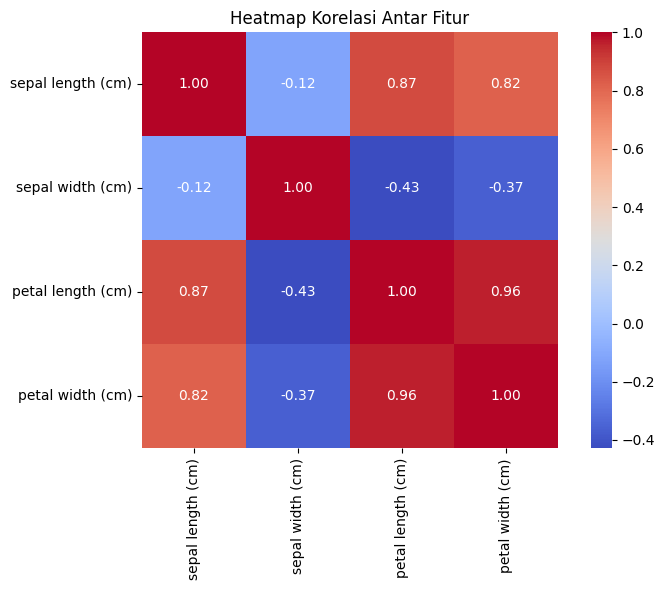

In [7]:
# --- 4.5 Heatmap Korelasi ---
plt.figure(figsize=(8, 6))
corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

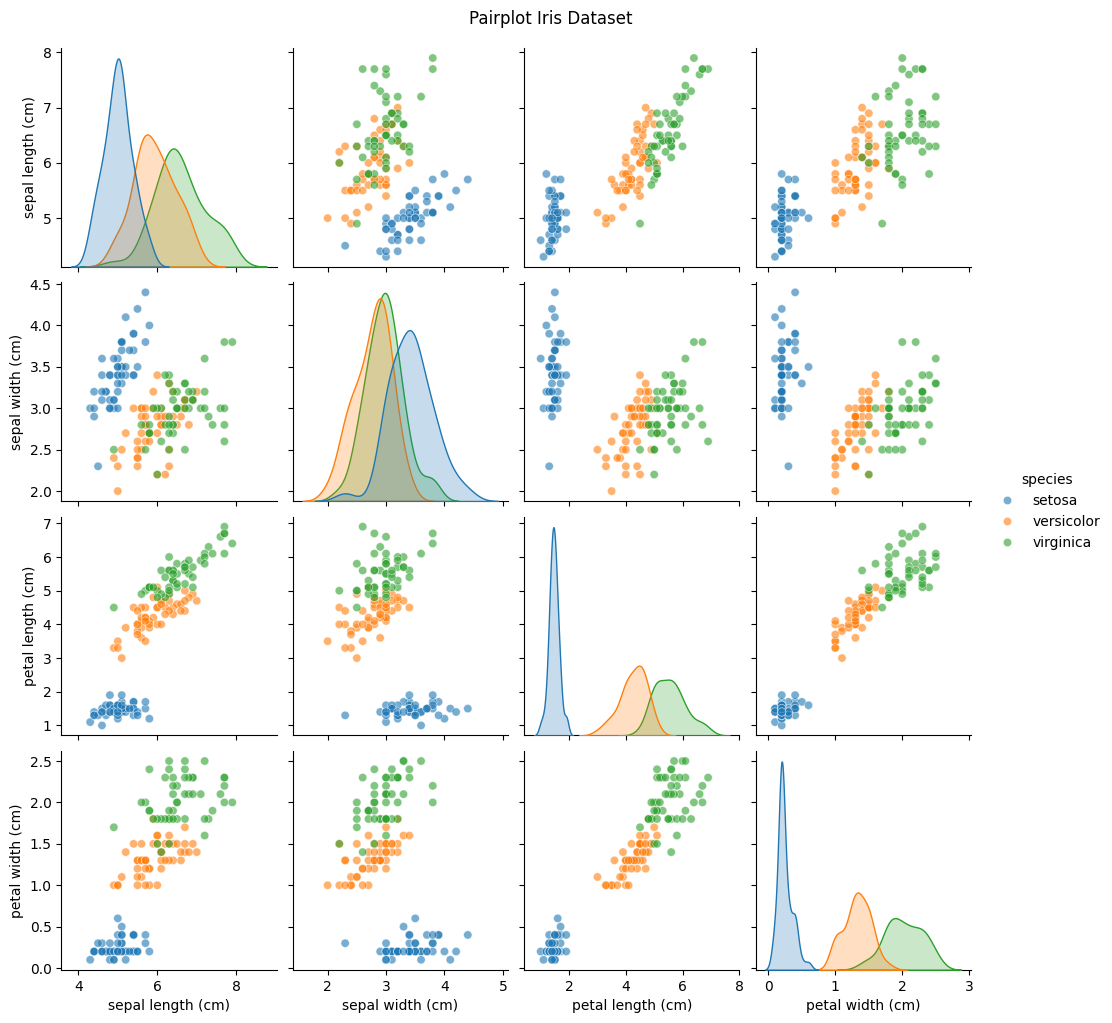

In [8]:
# --- 4.6 Pairplot ---
sns.pairplot(df, hue='species', vars=iris.feature_names, plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot Iris Dataset', y=1.02)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

Tahapan preprocessing yang dilakukan:
1. Menghapus kolom non-fitur (`species`)
2. Memisahkan fitur (X) dan label (y)
3. Normalisasi fitur menggunakan StandardScaler
4. Split data menjadi train dan test set (80:20)
5. Menyimpan hasil preprocessing ke file `.npy`

In [9]:
# --- 5.1 Pisahkan fitur dan label ---
X = df[iris.feature_names].values
y = df['target'].values

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')

Shape X: (150, 4)
Shape y: (150,)


In [10]:
# --- 5.2 Normalisasi dengan StandardScaler ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Sebelum scaling (mean, std):')
print(f'  mean: {X.mean(axis=0).round(3)}')
print(f'  std : {X.std(axis=0).round(3)}')

print('\nSetelah scaling (mean, std):')
print(f'  mean: {X_scaled.mean(axis=0).round(3)}')
print(f'  std : {X_scaled.std(axis=0).round(3)}')

Sebelum scaling (mean, std):
  mean: [5.843 3.057 3.758 1.199]
  std : [0.825 0.434 1.759 0.76 ]

Setelah scaling (mean, std):
  mean: [-0. -0. -0. -0.]
  std : [1. 1. 1. 1.]


In [11]:
# --- 5.3 Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # pastikan distribusi kelas proporsional
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'y_train distribusi: {np.bincount(y_train)}')
print(f'y_test  distribusi: {np.bincount(y_test)}')

X_train shape: (120, 4)
X_test shape : (30, 4)
y_train distribusi: [40 40 40]
y_test  distribusi: [10 10 10]


In [12]:
# --- 5.4 Simpan hasil preprocessing ---
os.makedirs('iris_preprocessing', exist_ok=True)

np.save('iris_preprocessing/X_train.npy', X_train)
np.save('iris_preprocessing/X_test.npy',  X_test)
np.save('iris_preprocessing/y_train.npy', y_train)
np.save('iris_preprocessing/y_test.npy',  y_test)

print('Preprocessing selesai! File tersimpan di folder iris_preprocessing/')
print(os.listdir('iris_preprocessing'))

Preprocessing selesai! File tersimpan di folder iris_preprocessing/
['y_train.npy', 'X_test.npy', 'y_test.npy', 'X_train.npy']
